# 과제 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('신뢰성공학_과제데이터.xlsx')

df

,Days,Type
0,492,1
1,760,1
2,394,1
3,421,1
4,578,1
...,...,...
74,446,2
75,123,2
76,235,2
77,294,2


In [3]:
df['Type'].unique()

array([1, 2])

In [4]:
df['Days'].describe()

count     79.000000
mean     427.594937
std      207.967238
min       49.000000
25%      276.000000
50%      449.000000
75%      537.000000
max      760.000000
Name: Days, dtype: float64

In [5]:
index = ['({0} : {1}]'.format(t, t+50) for t in range(0,800,50)]

index

['(0 : 50]',
 '(50 : 100]',
 '(100 : 150]',
 '(150 : 200]',
 '(200 : 250]',
 '(250 : 300]',
 '(300 : 350]',
 '(350 : 400]',
 '(400 : 450]',
 '(450 : 500]',
 '(500 : 550]',
 '(550 : 600]',
 '(600 : 650]',
 '(650 : 700]',
 '(700 : 750]',
 '(750 : 800]']

In [6]:
cdf = pd.DataFrame(index=index, columns=['Type1', 'Type2'])

cdf

,Type1,Type2
(0 : 50],NaN,NaN
(50 : 100],NaN,NaN
(100 : 150],NaN,NaN
(150 : 200],NaN,NaN
(200 : 250],NaN,NaN
(250 : 300],NaN,NaN
(300 : 350],NaN,NaN
(350 : 400],NaN,NaN
(400 : 450],NaN,NaN
(450 : 500],NaN,NaN


In [7]:
type1_df = df[df['Type']==1]
type2_df = df[df['Type']==2]

type1_df

,Days,Type
0,492,1
1,760,1
2,394,1
3,421,1
4,578,1
5,754,1
6,332,1
7,474,1
8,530,1
9,760,1


In [8]:
type2_df

,Days,Type
38,233,2
39,241,2
40,307,2
41,403,2
42,541,2
43,323,2
44,533,2
45,203,2
46,272,2
47,494,2


# 도수분포표

In [9]:
for i,t in zip(cdf.index, range(0,800,50)):
    cdf.loc[i, 'Type1'] = sum(type1_df['Days'] <= t+50)
    cdf.loc[i, 'Type2'] = sum(type2_df['Days'] <= t+50)

cdf

,Type1,Type2
(0 : 50],0,1
(50 : 100],1,5
(100 : 150],2,8
(150 : 200],2,9
(200 : 250],2,17
(250 : 300],3,20
(300 : 350],7,23
(350 : 400],9,24
(400 : 450],11,30
(450 : 500],15,39


# 신뢰도(R(t))

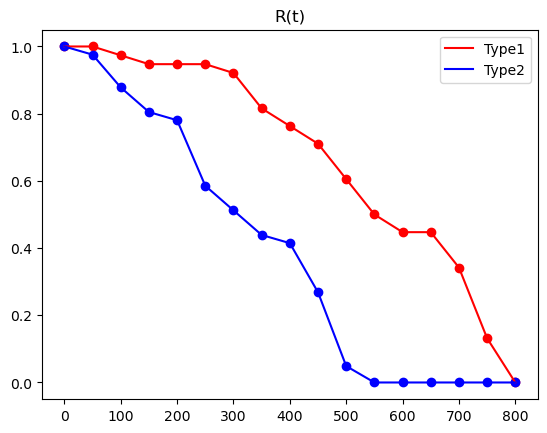

In [10]:
t = range(0,850,50)

type1_Rt = [1] + [1 - x/len(type1_df['Days']) for x in cdf['Type1']]
type2_Rt = [1] + [1 - x/len(type2_df['Days']) for x in cdf['Type2']]

plt.plot(t, type1_Rt, color='r', label='Type1')
plt.plot(t, type2_Rt, color='b', label='Type2')

plt.scatter(t, type1_Rt, color='r')
plt.scatter(t, type2_Rt, color='b')

plt.title('R(t)')
plt.legend()
plt.show()

# 불신뢰도(F(t))

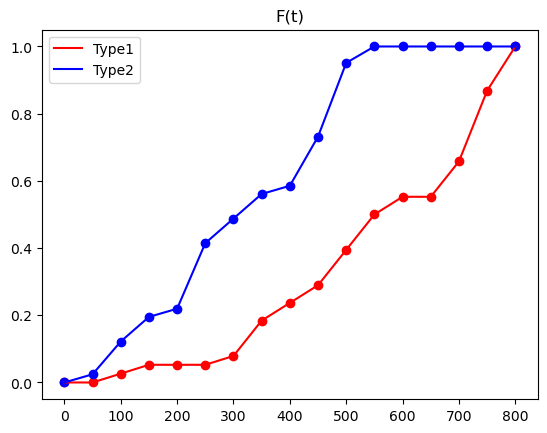

In [11]:
t = range(0,850,50)

type1_Ft = [0] + [x/len(type1_df['Days']) for x in cdf['Type1']]
type2_Ft = [0] + [x/len(type2_df['Days']) for x in cdf['Type2']]

plt.plot(t, type1_Ft, color='r', label='Type1')
plt.plot(t, type2_Ft, color='b', label='Type2')

plt.scatter(t, type1_Ft, color='r')
plt.scatter(t, type2_Ft, color='b')

plt.title('F(t)')
plt.legend()
plt.show()

# 고장확률밀도함수(f(t))

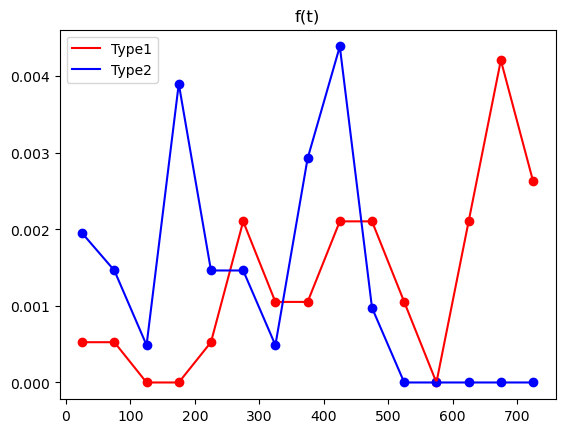

In [12]:
t = [t_+25 for t_ in range(0,750,50)]

type1_ft = []
type2_ft = []

for i in range(len(cdf.index)-1):
    type1_ft.append((cdf.iloc[i+1,0]-cdf.iloc[i,0])/(len(type1_df['Days'])*50))

for i in range(len(cdf.index)-1):
    type2_ft.append((cdf.iloc[i+1,1]-cdf.iloc[i,1])/(len(type2_df['Days'])*50))

plt.plot(t, type1_ft, color='r', label='Type1')
plt.plot(t, type2_ft, color='b', label='Type2')

plt.scatter(t, type1_ft, color='r')
plt.scatter(t, type2_ft, color='b')

plt.title('f(t)')
plt.legend()
plt.show()

# 고장률(h(t))

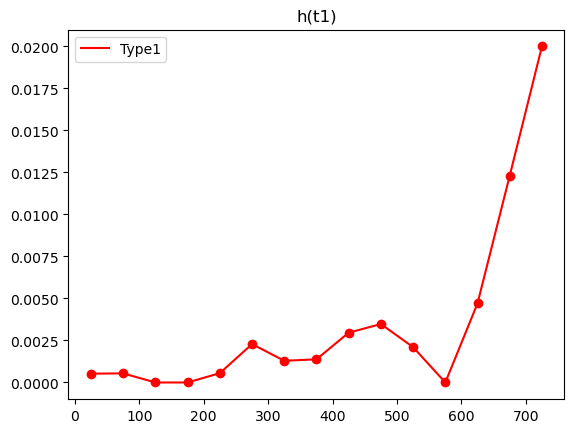

In [13]:
t1 = [t+25 for t in range(0,750,50)]

type1_ht = []

for i in range(len(cdf.index)-1):
    type1_ht.append((cdf.iloc[i+1,0]-cdf.iloc[i,0])/
                    ((len(type1_df['Days'])-cdf.iloc[i,0])*50))

plt.plot(t1, type1_ht, color='r',label='Type1')

plt.scatter(t1, type1_ht, color='r')

plt.title('h(t1)')
plt.legend()
plt.show()

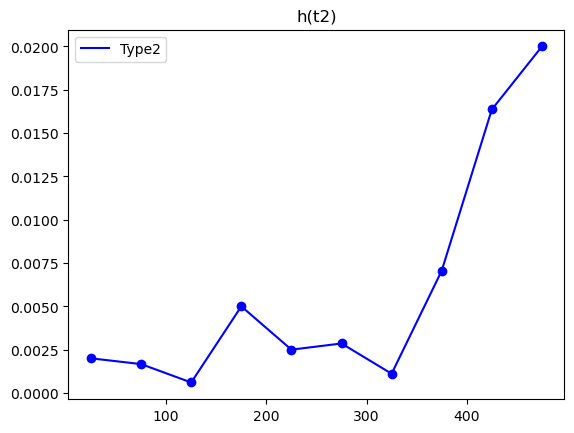

In [14]:
t2 = [t+25 for t in range(0,500,50)]

type2_ht = []

for i in range(len(cdf.index)-1):
    if (len(type2_df['Days'])-cdf.iloc[i,1]) > 0:
        type2_ht.append((cdf.iloc[i+1,1]-cdf.iloc[i,1])/
                        ((len(type2_df['Days'])-cdf.iloc[i,1])*50))

plt.plot(t2, type2_ht, color='b',label='Type2')

plt.scatter(t2, type2_ht, color='b')

plt.title('h(t2)')
plt.legend()
plt.show()

# 과제 2

In [15]:
!pip install reliability matplotlib

In [16]:
from reliability.Fitters import Fit_Weibull_2P
import reliability.Distributions

# Type1

In [17]:
type1_failure = type1_df['Days'].tolist()

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 38/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         610.074         30.9271   552.372   673.803
     Beta         3.32712        0.461953   2.53445   4.36771 

Goodness of fit    Value
 Log-likelihood -253.776
           AICc  511.894
            BIC  514.826
             AD  1.64266 



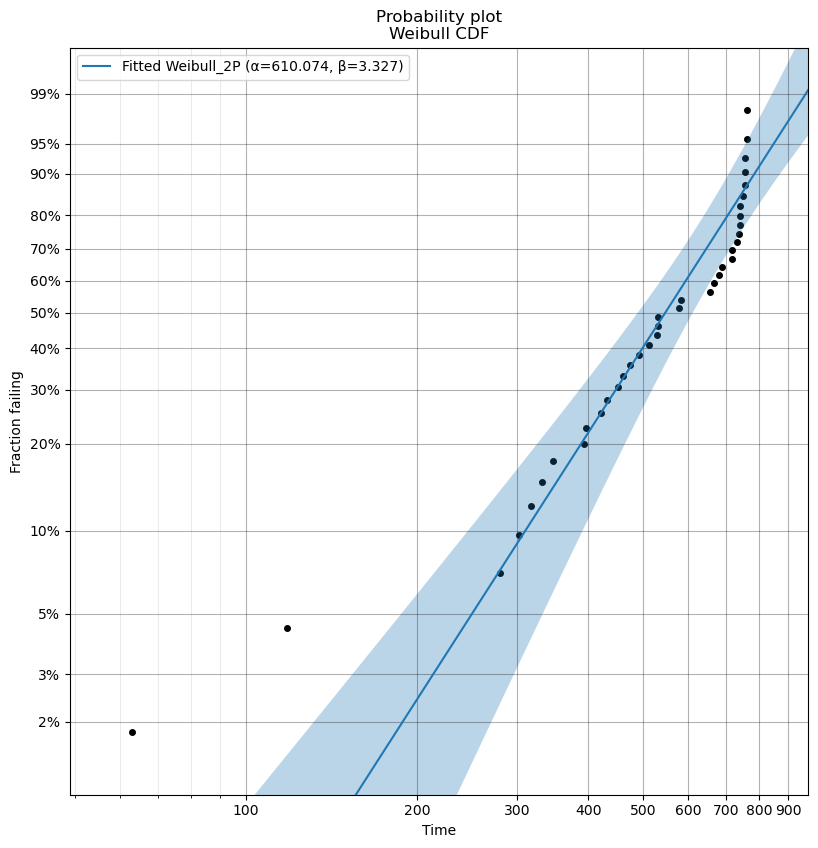

In [18]:
fit_1 = Fit_Weibull_2P(failures=type1_failure)

array([1.00000000e+00, 9.99900000e-01, 9.99845387e-01, 9.99772727e-01,
       9.99679031e-01, 9.99561198e-01, 9.99416031e-01, 9.99240242e-01,
       9.99030456e-01, 9.98783219e-01, 9.98495002e-01, 9.98162210e-01,
       9.97781182e-01, 9.97348198e-01, 9.96859483e-01, 9.96311215e-01,
       9.95699524e-01, 9.95020500e-01, 9.94270198e-01, 9.93444643e-01,
       9.92539831e-01, 9.91551739e-01, 9.90476327e-01, 9.89309544e-01,
       9.88047334e-01, 9.86685639e-01, 9.85220408e-01, 9.83647602e-01,
       9.81963195e-01, 9.80163189e-01, 9.78243613e-01, 9.76200531e-01,
       9.74030051e-01, 9.71728329e-01, 9.69291578e-01, 9.66716072e-01,
       9.63998156e-01, 9.61134254e-01, 9.58120872e-01, 9.54954610e-01,
       9.51632167e-01, 9.48150350e-01, 9.44506081e-01, 9.40696406e-01,
       9.36718502e-01, 9.32569683e-01, 9.28247412e-01, 9.23749307e-01,
       9.19073147e-01, 9.14216883e-01, 9.09178645e-01, 9.03956746e-01,
       8.98549696e-01, 8.92956205e-01, 8.87175190e-01, 8.81205784e-01,
      

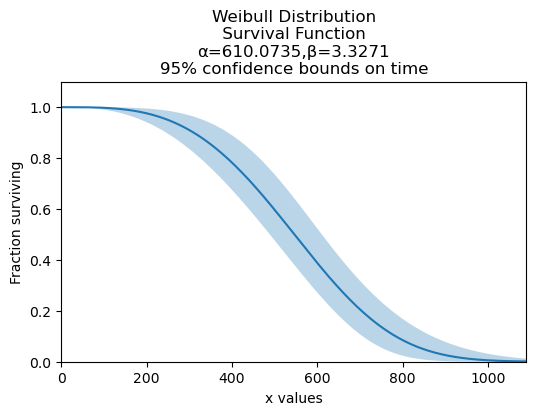

In [19]:
plt.figure(figsize=(6,4))
fit_1.distribution.SF(label='Weibull R(t)')

array([0.00000000e+00, 1.00000000e-04, 1.54613299e-04, 2.27272618e-04,
       3.20969439e-04, 4.38802315e-04, 5.83968691e-04, 7.59757743e-04,
       9.69543954e-04, 1.21678125e-03, 1.50499752e-03, 1.83778951e-03,
       2.21881782e-03, 2.65180215e-03, 3.14051662e-03, 3.68878506e-03,
       4.30047647e-03, 4.97950031e-03, 5.72980181e-03, 6.55535725e-03,
       7.46016909e-03, 8.44826103e-03, 9.52367299e-03, 1.06904559e-02,
       1.19526663e-02, 1.33143610e-02, 1.47795916e-02, 1.63523984e-02,
       1.80368047e-02, 1.98368106e-02, 2.17563870e-02, 2.37994688e-02,
       2.59699488e-02, 2.82716707e-02, 3.07084222e-02, 3.32839283e-02,
       3.60018437e-02, 3.88657460e-02, 4.18791279e-02, 4.50453901e-02,
       4.83678330e-02, 5.18496500e-02, 5.54939186e-02, 5.93035936e-02,
       6.32814983e-02, 6.74303172e-02, 7.17525880e-02, 7.62506933e-02,
       8.09268531e-02, 8.57831168e-02, 9.08213554e-02, 9.60432539e-02,
       1.01450304e-01, 1.07043795e-01, 1.12824810e-01, 1.18794216e-01,
      

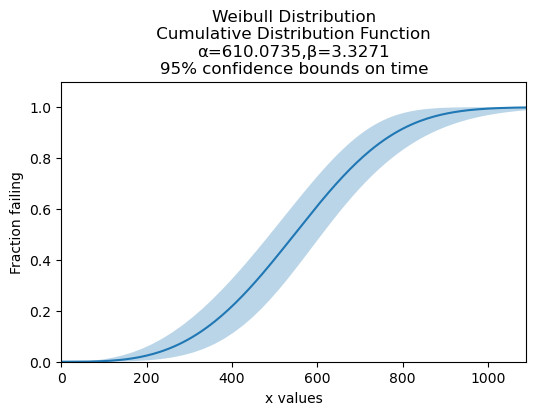

In [20]:
plt.figure(figsize=(6,4))
fit_1.distribution.CDF(label='Weibull F(t)')

array([0.00000000e+00, 8.68757584e-06, 1.17828401e-05, 1.54257378e-05,
       1.96370890e-05, 2.44360730e-05, 2.98404477e-05, 3.58667102e-05,
       4.25302163e-05, 4.98452685e-05, 5.78251821e-05, 6.64823325e-05,
       7.58281896e-05, 8.58733395e-05, 9.66274984e-05, 1.08099518e-04,
       1.20297386e-04, 1.33228220e-04, 1.46898254e-04, 1.61312830e-04,
       1.76476376e-04, 1.92392391e-04, 2.09063415e-04, 2.26491011e-04,
       2.44675739e-04, 2.63617123e-04, 2.83313629e-04, 3.03762632e-04,
       3.24960390e-04, 3.46902008e-04, 3.69581417e-04, 3.92991335e-04,
       4.17123244e-04, 4.41967360e-04, 4.67512604e-04, 4.93746575e-04,
       5.20655530e-04, 5.48224350e-04, 5.76436530e-04, 6.05274148e-04,
       6.34717856e-04, 6.64746858e-04, 6.95338902e-04, 7.26470264e-04,
       7.58115749e-04, 7.90248681e-04, 8.22840904e-04, 8.55862788e-04,
       8.89283231e-04, 9.23069677e-04, 9.57188126e-04, 9.91603154e-04,
       1.02627794e-03, 1.06117429e-03, 1.09625269e-03, 1.13147230e-03,
      

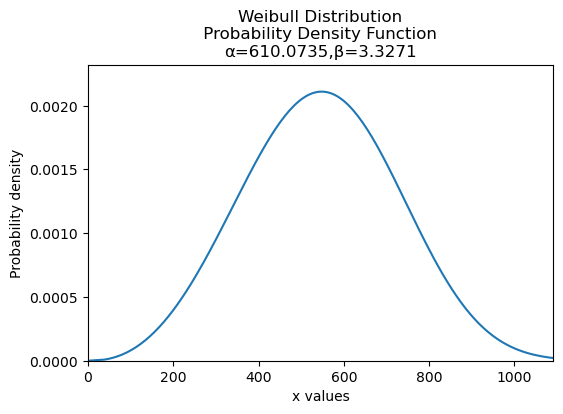

In [21]:
plt.figure(figsize=(6,4))
fit_1.distribution.PDF(label='Weibull f(t)')

array([0.00000000e+00, 8.68844468e-06, 1.17846621e-05, 1.54292444e-05,
       1.96433939e-05, 2.44468003e-05, 2.98578838e-05, 3.58939810e-05,
       4.25714912e-05, 4.99059932e-05, 5.79123400e-05, 6.66047380e-05,
       7.59968127e-05, 8.61016641e-05, 9.69319147e-05, 1.08499751e-04,
       1.20816957e-04, 1.33894949e-04, 1.47744802e-04, 1.62377271e-04,
       1.77802815e-04, 1.94031621e-04, 2.11073611e-04, 2.28938468e-04,
       2.47635645e-04, 2.67174379e-04, 2.87563703e-04, 3.08812456e-04,
       3.30929297e-04, 3.53922706e-04, 3.77801002e-04, 4.02572343e-04,
       4.28244738e-04, 4.54826052e-04, 4.82324013e-04, 5.10746216e-04,
       5.40100130e-04, 5.70393104e-04, 6.01632369e-04, 6.33825045e-04,
       6.66978144e-04, 7.01098574e-04, 7.36193144e-04, 7.72268565e-04,
       8.09331456e-04, 8.47388346e-04, 8.86445676e-04, 9.26509803e-04,
       9.67587003e-04, 1.00968347e-03, 1.05280533e-03, 1.09695863e-03,
       1.14214934e-03, 1.18838336e-03, 1.23566653e-03, 1.28400462e-03,
      

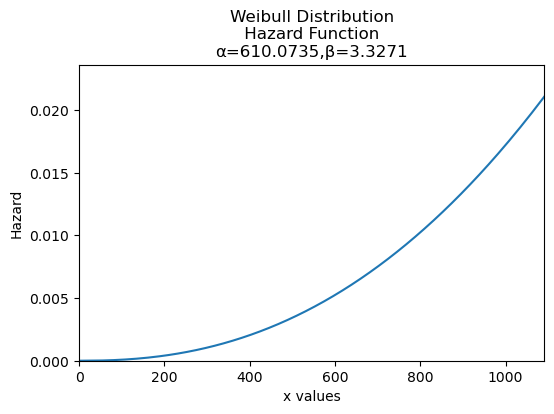

In [22]:
plt.figure(figsize=(6,4))
fit_1.distribution.HF(label='Weibull h(t)')

# Type2

In [23]:
type2_failure = type2_df['Days'].tolist()

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 41/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha           354.5         26.2455   306.618   409.859
     Beta         2.20687        0.292253   1.70237   2.86088 

Goodness of fit    Value
 Log-likelihood -263.538
           AICc  531.392
            BIC  534.503
             AD  1.54935 



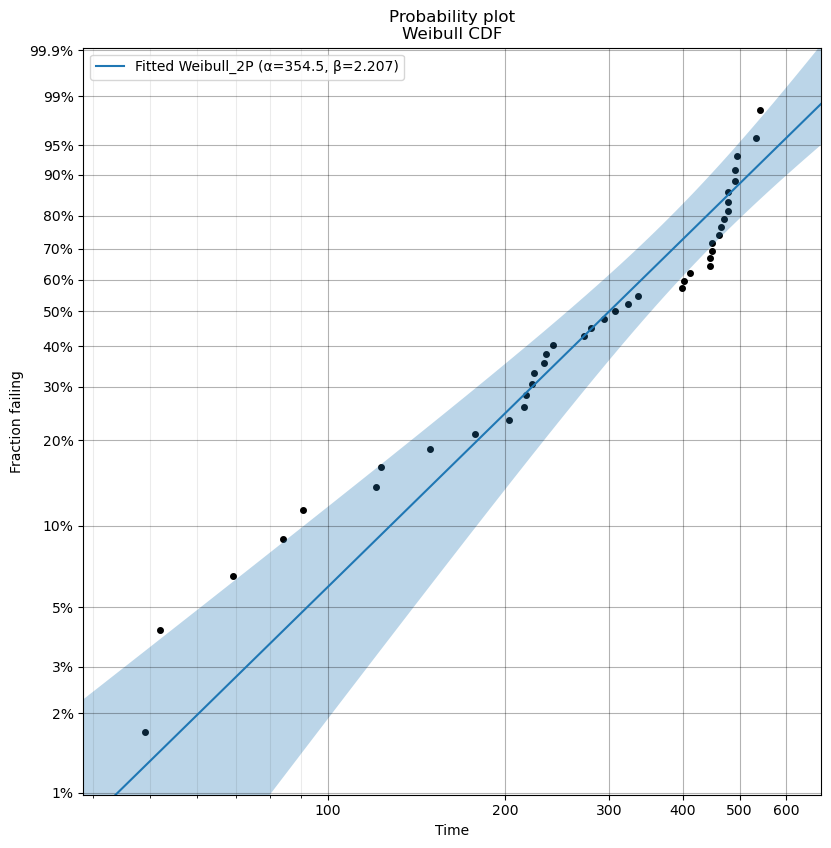

In [24]:
fit_2 = Fit_Weibull_2P(failures=type2_failure)

array([1.00000000e+00, 9.99900000e-01, 9.99658748e-01, 9.99252618e-01,
       9.98669004e-01, 9.97898249e-01, 9.96932538e-01, 9.95765353e-01,
       9.94391173e-01, 9.92805280e-01, 9.91003634e-01, 9.88982783e-01,
       9.86739799e-01, 9.84272231e-01, 9.81578068e-01, 9.78655707e-01,
       9.75503934e-01, 9.72121903e-01, 9.68509120e-01, 9.64665430e-01,
       9.60591005e-01, 9.56286335e-01, 9.51752215e-01, 9.46989743e-01,
       9.42000304e-01, 9.36785570e-01, 9.31347489e-01, 9.25688279e-01,
       9.19810419e-01, 9.13716647e-01, 9.07409947e-01, 9.00893548e-01,
       8.94170914e-01, 8.87245736e-01, 8.80121928e-01, 8.72803617e-01,
       8.65295136e-01, 8.57601018e-01, 8.49725985e-01, 8.41674945e-01,
       8.33452979e-01, 8.25065335e-01, 8.16517419e-01, 8.07814786e-01,
       7.98963133e-01, 7.89968290e-01, 7.80836206e-01, 7.71572949e-01,
       7.62184688e-01, 7.52677688e-01, 7.43058302e-01, 7.33332958e-01,
       7.23508152e-01, 7.13590436e-01, 7.03586414e-01, 6.93502726e-01,
      

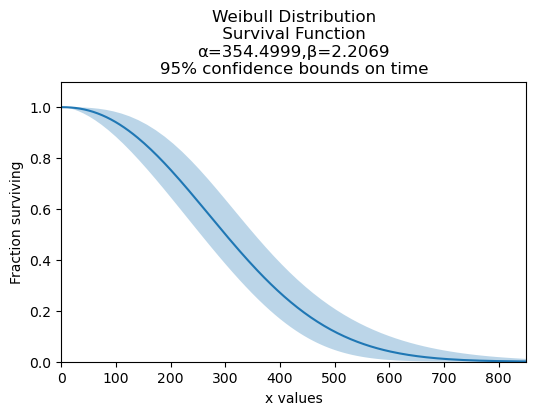

In [25]:
plt.figure(figsize=(6,4))
fit_2.distribution.SF(label='Weibull R(t)')

array([0.00000000e+00, 1.00000000e-04, 3.41252305e-04, 7.47381854e-04,
       1.33099586e-03, 2.10175056e-03, 3.06746236e-03, 4.23464741e-03,
       5.60882742e-03, 7.19472010e-03, 8.99636600e-03, 1.10172170e-02,
       1.32602008e-02, 1.57277686e-02, 1.84219323e-02, 2.13442935e-02,
       2.44960664e-02, 2.78780974e-02, 3.14908803e-02, 3.53345701e-02,
       3.94089948e-02, 4.37136652e-02, 4.82477848e-02, 5.30102575e-02,
       5.79996962e-02, 6.32144298e-02, 6.86525106e-02, 7.43117210e-02,
       8.01895807e-02, 8.62833533e-02, 9.25900529e-02, 9.91064516e-02,
       1.05829086e-01, 1.12754264e-01, 1.19878072e-01, 1.27196383e-01,
       1.34704864e-01, 1.42398982e-01, 1.50274015e-01, 1.58325055e-01,
       1.66547021e-01, 1.74934665e-01, 1.83482581e-01, 1.92185214e-01,
       2.01036867e-01, 2.10031710e-01, 2.19163794e-01, 2.28427051e-01,
       2.37815312e-01, 2.47322312e-01, 2.56941698e-01, 2.66667042e-01,
       2.76491848e-01, 2.86409564e-01, 2.96413586e-01, 3.06497274e-01,
      

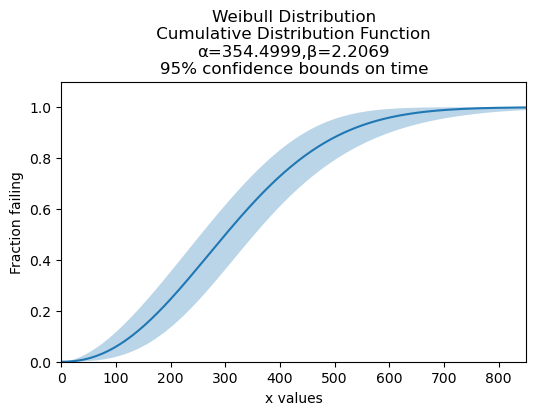

In [26]:
plt.figure(figsize=(6,4))
fit_2.distribution.CDF(label='Weibull F(t)')

array([0.00000000e+00, 4.04251817e-05, 7.90857888e-05, 1.21383906e-04,
       1.66356910e-04, 2.13451143e-04, 2.62293655e-04, 3.12608316e-04,
       3.64177117e-04, 4.16819704e-04, 4.70381488e-04, 5.24726274e-04,
       5.79731436e-04, 6.35284646e-04, 6.91281577e-04, 7.47624258e-04,
       8.04219865e-04, 8.60979829e-04, 9.17819161e-04, 9.74655944e-04,
       1.03141095e-03, 1.08800732e-03, 1.14437041e-03, 1.20042754e-03,
       1.25610792e-03, 1.31134257e-03, 1.36606423e-03, 1.42020735e-03,
       1.47370806e-03, 1.52650414e-03, 1.57853508e-03, 1.62974207e-03,
       1.68006798e-03, 1.72945749e-03, 1.77785700e-03, 1.82521479e-03,
       1.87148095e-03, 1.91660750e-03, 1.96054839e-03, 2.00325955e-03,
       2.04469892e-03, 2.08482653e-03, 2.12360448e-03, 2.16099701e-03,
       2.19697054e-03, 2.23149368e-03, 2.26453726e-03, 2.29607436e-03,
       2.32608036e-03, 2.35453289e-03, 2.38141192e-03, 2.40669973e-03,
       2.43038091e-03, 2.45244239e-03, 2.47287344e-03, 2.49166563e-03,
      

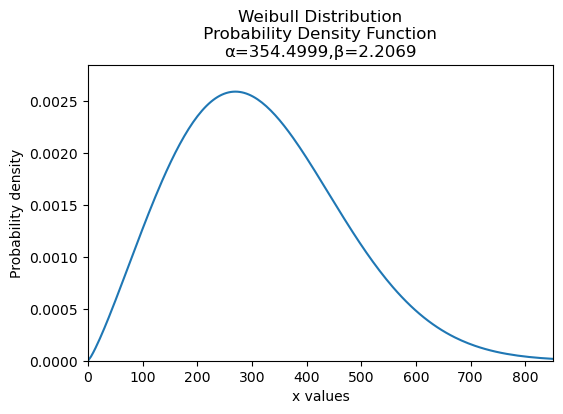

In [27]:
plt.figure(figsize=(6,4))
fit_2.distribution.PDF(label='Weibull f(t)')

array([0.00000000e+00, 4.04292246e-05, 7.91127862e-05, 1.21474694e-04,
       1.66578626e-04, 2.13900709e-04, 2.63100706e-04, 3.13937731e-04,
       3.66231245e-04, 4.19840337e-04, 4.74651628e-04, 5.30571697e-04,
       5.87522097e-04, 6.45435913e-04, 7.04255321e-04, 7.63929799e-04,
       8.24414784e-04, 8.85670642e-04, 9.47661868e-04, 1.01035646e-03,
       1.07372538e-03, 1.13774221e-03, 1.20238271e-03, 1.26762464e-03,
       1.33344747e-03, 1.39983216e-03, 1.46676106e-03, 1.53421771e-03,
       1.60218674e-03, 1.67065375e-03, 1.73960522e-03, 1.80902846e-03,
       1.87891147e-03, 1.94924294e-03, 2.02001217e-03, 2.09120901e-03,
       2.16282384e-03, 2.23484751e-03, 2.30727131e-03, 2.38008694e-03,
       2.45328647e-03, 2.52686235e-03, 2.60080732e-03, 2.67511446e-03,
       2.74977712e-03, 2.82478893e-03, 2.90014377e-03, 2.97583575e-03,
       3.05185921e-03, 3.12820869e-03, 3.20487896e-03, 3.28186494e-03,
       3.35916175e-03, 3.43676466e-03, 3.51466912e-03, 3.59287071e-03,
      

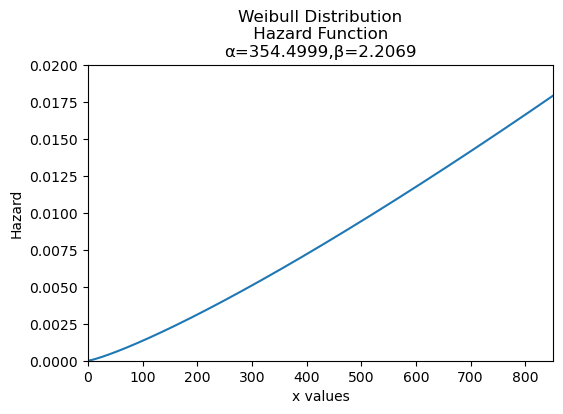

In [28]:
plt.figure(figsize=(6,4))
fit_2.distribution.HF(label='Weibull h(t)')